In [1]:
import utils
import model
import layers
from torch import optim
from torch.utils import data
from torchvision import datasets, transforms
from IPython import display

In [2]:
m = model.UNet(3, 64, 128, 256, positional_encoding_type = layers.PositionalEncoding2d)
m = model.DDPM(m)
opt = optim.Adam(m.parameters(), 2e-4)

batch_size = 100

tf = transforms.Compose([
    transforms.ToTensor(),
])
train_set = datasets.CIFAR10('D:/data/CIFAR10', train=True, download=True, transform=tf)
train_dl = data.DataLoader(train_set, batch_size, shuffle=True)


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:07<00:00,  3.74s/it]

Demo saved to d:\myProjects\python\HQ-50K\model\demo_0.png



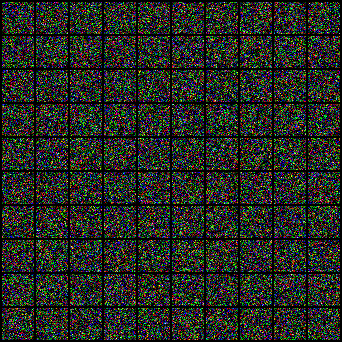

Loss: 1.837937:   0%|          | 0/500 [00:11<?, ?it/s]


KeyboardInterrupt: 

In [4]:
grid = utils.demo(m, (32, 32), 2, 10, filename='demo_0.png')
display.display(display.Image('demo_0.png'))
for i in range(10):
    utils.train(m, train_dl, opt)
    grid = utils.demo(m, (32, 32), 50, 10, filename=f'demo_{i+1}.png')
    display.display(display.Image(f'demo_{i+1}.png'))